##1.Import


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

##2.Load Data

In [4]:
df = pd.read_csv("matches.csv")
df.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [5]:
df.columns

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='object')

##3.Toss Impact

In [15]:
df['toss_win_match_win'] = df['toss_winner'] == df['winner']

toss_win_pct = df['toss_win_match_win'].mean() * 100

print(toss_win_pct)

50.825688073394495


###Toss winners win approximately **50.82%** of matches

###This shows that
- Toss gives little advantage
- It doesn't guarantee victory

##4.Decision Impact

In [16]:
decision_stats = df.groupby('toss_decision')['toss_win_match_win'].mean() * 100
decision_stats

,toss_win_match_win
toss_decision,
bat,45.384615
field,53.857143


###The analysis shows that teams choosing to field first tend to win more matches compared to batting first.

##5.Season-wise trend

In [18]:
season_decision = df.groupby(['season', 'toss_decision'])['toss_win_match_win'].mean().unstack() * 100

season_decision.head()

toss_decision,bat,field
season,,
2007/08,34.615385,59.375000
2009,54.285714,63.636364
2009/10,53.846154,47.619048
2011,45.833333,56.250000
2012,40.540541,48.648649


### analyzed how toss decisions perform across different seasons.

##6.Visualization

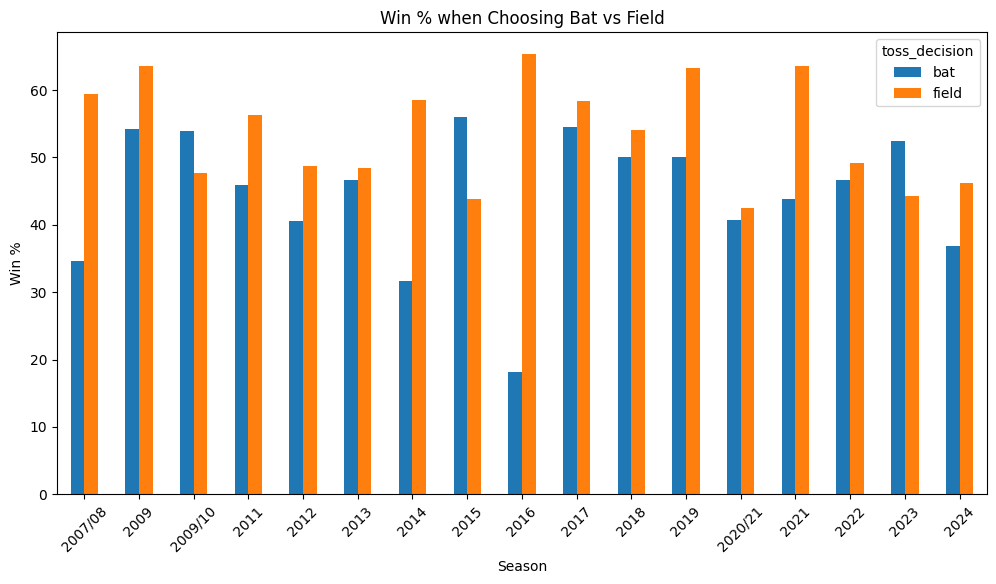

In [20]:
season_decision.plot(kind='bar', figsize=(12,6))

plt.title("Win % when Choosing Bat vs Field")
plt.xlabel("Season")
plt.ylabel("Win %")
plt.xticks(rotation=45)

plt.show()

###The bar chart shows win percentages for:
- Batting first
- Fielding first

Insight:
- In earlier seasons, the difference is small
- In later seasons, fielding first shows higher win rates

This suggests that chasing has become more effective over time.

## Final Verdict

Winning the toss provides only a slight advantage, as toss winners win around **50%** of matches.

However, the decision made after winning the toss plays a more important role.

Teams that choose to **field first** tend to win more matches, especially in recent seasons.



### Conclusion:
- Toss itself is **not very impactful**
- The **decision (bat/field)** matters more
- Fielding first is generally the better strategy